Titanic

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib as plt

In [2]:
file_path = "C:/Users/neptu/.kaggle/competitions/titanic"
training_data = pd.read_csv(f"{file_path}/train.csv")
test_data = pd.read_csv(f"{file_path}/test.csv")
training_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Gender**

Test the survival rate between genders

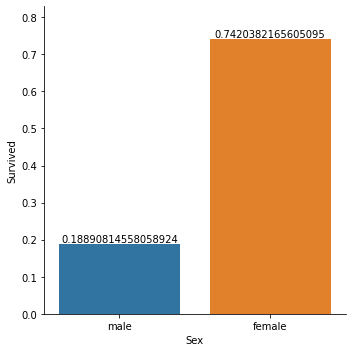

In [3]:
g = sns.catplot(data=training_data, kind="bar", errwidth=0, x='Sex', y="Survived")
ax = g.facet_axis(0,0)

for c in ax.containers:
    labels = [v.get_height() for v in c]
    ax.bar_label(c, labels=labels)

**Age**

Fill in all empty cells for age<br>
Determine how age affect survivability

In [4]:
for i in [training_data, test_data]:
    i["Age"].fillna(i["Age"].mean(), inplace=True)

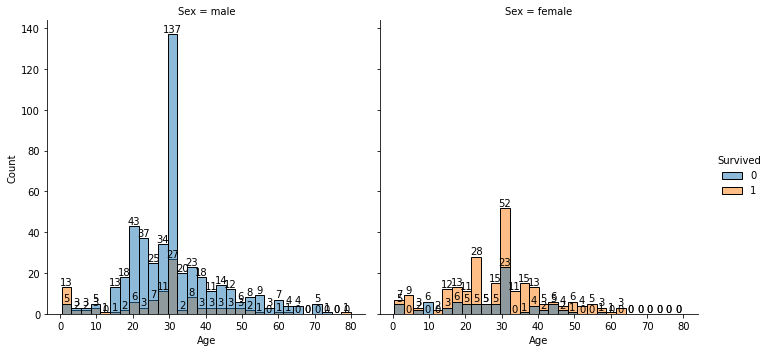

In [5]:
g = sns.displot(training_data, x="Age", col="Sex", hue="Survived")

for ax in g.axes.ravel():
    for c in ax.containers:
        print
        labels = [v.get_height() for v in c]
        ax.bar_label(c, labels=labels)

In [9]:
for i in [training_data, test_data]:
    a = i[["Pclass", "Fare"]].groupby("Pclass").mean()
    i.Fare= i.Fare.fillna(i.Pclass.map(dict(a["Fare"])))

training_data["Pclass"] = training_data["Pclass"].astype(str)
test_data["Pclass"] = test_data["Pclass"].astype(str) 

**Machine Learning**

Using feature engineering to test whether people survived based on key characteristics

In [10]:
target = training_data["Survived"]
features = ["Sex", "Age", "SibSp", "Parch", "Fare", "Embarked", "Pclass"]

train_X = pd.get_dummies(training_data[features])
test_X = pd.get_dummies(test_data[features])

train_X

,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass_1,Pclass_2,Pclass_3
0,22.000000,1,0,7.2500,0,1,0,0,1,0,0,1
1,38.000000,1,0,71.2833,1,0,1,0,0,1,0,0
2,26.000000,0,0,7.9250,1,0,0,0,1,0,0,1
3,35.000000,1,0,53.1000,1,0,0,0,1,1,0,0
4,35.000000,0,0,8.0500,0,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,27.000000,0,0,13.0000,0,1,0,0,1,0,1,0
887,19.000000,0,0,30.0000,1,0,0,0,1,1,0,0
888,29.699118,1,2,23.4500,1,0,0,0,1,0,0,1
889,26.000000,0,0,30.0000,0,1,1,0,0,1,0,0


In [8]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(random_state=1, n_estimators=100)
forest_model.fit(train_X, target)
prediction = forest_model.predict(test_X).astype(int)

prediction = pd.DataFrame({'PassengerId': test_data["PassengerId"],'Survived':prediction})
prediction.to_csv("submission.csv", mode="w+", index=False)